A

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def ode(t, y, beta, gamma):
    """
    ODE
    """
    S, I, R = y
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR =  gamma * I
    return dS, dI, dR

def simulate(beta, gamma, S0, I0, R0, t_span=(0, 150), t_eval=None, method="RK45",
                 rtol=1e-8, atol=1e-10):
    """
    Simulate the SIR system using Runge-Kutta.
    """
    y0 = [S0, I0, R0]
    t_eval = np.linspace(t_span[0], t_span[1], 1500)
    sol = solve_ivp(
        fun=lambda t, y: ode(t, y, beta, gamma),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method=method,
        rtol=rtol,
        atol=atol,
        vectorized=False
    )
    S, I, R = sol.y
    return sol.t, S, I, R, sol

B

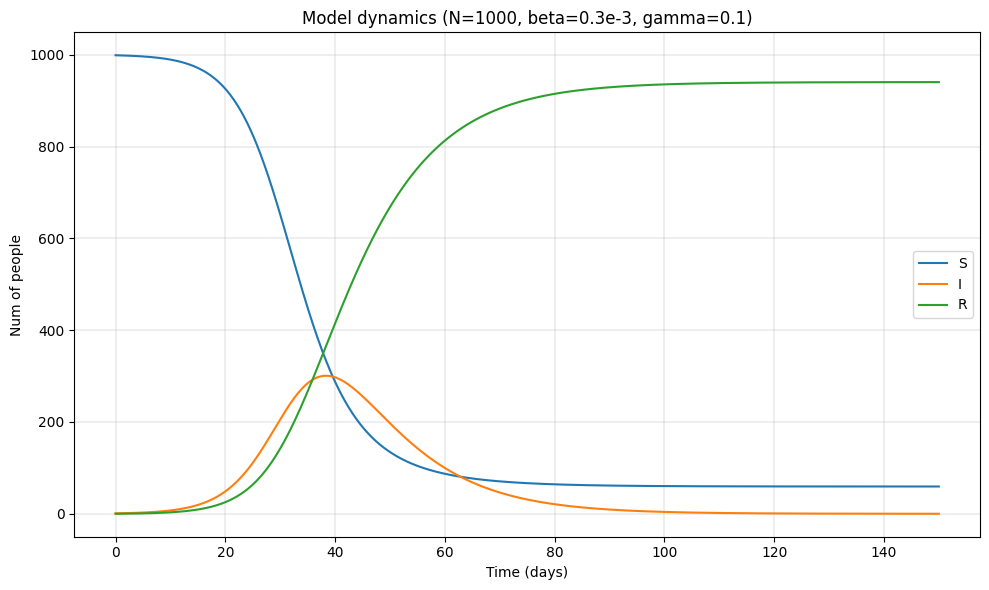

In [2]:
N = 1000
S0, I0, R0 = 999, 1, 0
beta = 0.3e-3
gamma = 0.1
t_span = (0, 150)

t, S, I, R, sol = simulate(beta, gamma, S0, I0, R0, t_span=t_span)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(t, S, label="S")
plt.plot(t, I, label="I")
plt.plot(t, R, label="R")
plt.xlabel("Time (days)")
plt.ylabel("Num of people")
plt.title("Model dynamics (N=1000, beta=0.3e-3, gamma=0.1)")
plt.legend()
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()


C
1.
From the figure, we observe that the number of infected individuals $I(t)$ reaches its maximum at around $t \approx 38$ days. From a mathematical perspective, the peak occurs when the derivative of $I$ vanishes:
$$
\frac{dI}{dt} = 0 \quad \Longrightarrow \quad \beta S I - \gamma I = 0.
$$
this yields
$$
\beta\,S = \gamma.
$$
Since $S(t)$ is strictly decreasing from its initial value $S_0$, the factors contributing to this peak are $S_0$, $\beta$, and $\gamma$.


2.
If \(S,I,R\) are not normalized, then
$$
\mathcal R_0=\frac{\beta S_0}{\gamma}
$$
in our question,
$$
\mathcal R_0=\frac{\beta}{\gamma}=3e-3
$$
From Eq1 and Eq2, we have
$$
\frac{dI}{dS}=-1+\frac{\gamma}{\beta S}
$$
we can conclude that $\mathcal R_0$ increases, the peak infected size inreseas and peak infected time decreases

when time approches inf, we have $I_\infty=0$, we can observe,
$$
\ln\!\Big(\frac{S_\infty}{S_0}\Big)
= -\frac{\beta}{\gamma}\,\big(R_\infty - R_{\mathrm{ini}}\big).
$$
Since $R_\infty = N - S_\infty$,
$$
\ln\!\Big(\frac{S_\infty}{S_0}\Big)
= -\frac{\beta}{\gamma}\,\big(N - S_\infty - R_{\mathrm{ini}}\big).
$$

Therefore, as $\mathcal R_0$ increases, $S_\infty$ increases and $R_\infty$ decreases

3.
from the previous analysis, we can conclude that S strictly decreases. I initially increases, peaks when $\beta\,S = \gamma
$, then decreases to 0. R strictly increases. the model dynamics is relative to the basic reproductive number $R_0$, when $R_0$ increases, indicades the Transmission rate is much faster than the Recovery rate, yieding larger peak infected size and shorter peak infected time; larger $S_\infty$ and smaller $R_\infty$, which correspond to interpretation from math perpective.





D

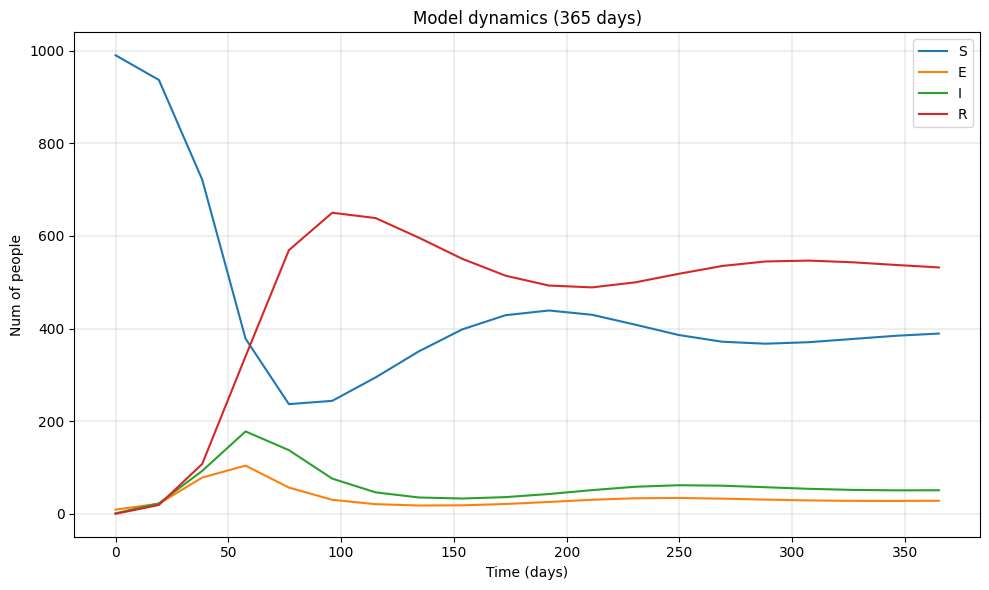

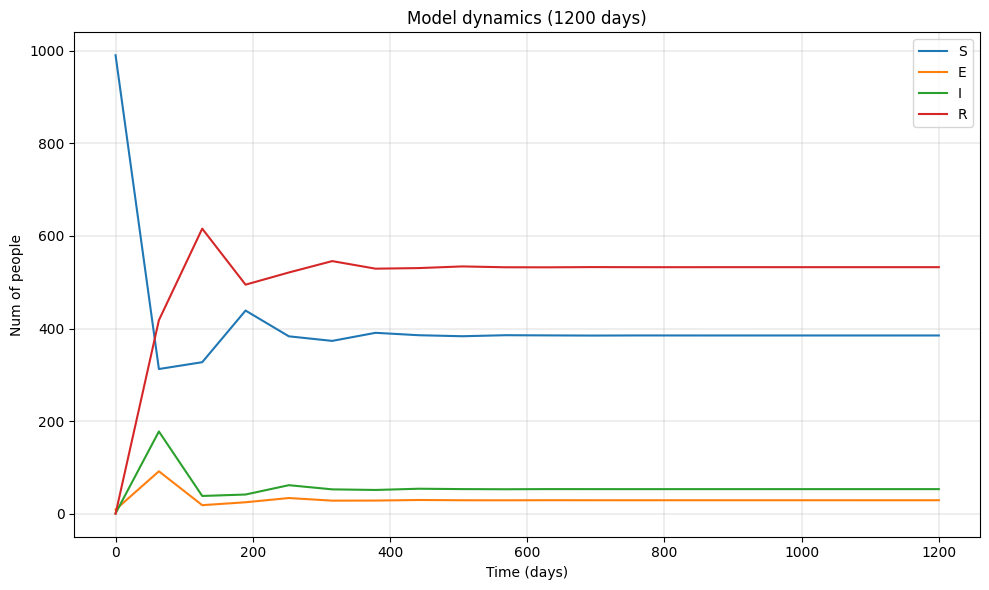

In [3]:
def ode_2(t, y, beta, gamma, sigma, mu):
    """
    ODE
    """
    S, E, I, R = y
    N = S + E + I + R
    dS = mu * N - beta * S * I - mu * S
    dE = beta * S * I - (sigma + mu) * E
    dI = sigma * E - (gamma + mu) * I
    dR = gamma * I - mu * R
    return dS, dE, dI, dR

def simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0,
                  t_span=(0, 365), t_eval=None, method="RK45",
                  rtol=1e-8, atol=1e-10):
    """
    Simulate the SIR system using Runge-Kutta.
    """
    y0 = [S0, E0, I0, R0]
    t_eval = np.linspace(t_span[0], t_span[1], 10*len(t_span))
    sol = solve_ivp(
        fun=lambda t, y: ode_2(t, y, beta, gamma, sigma, mu),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method=method,
        rtol=rtol,
        atol=atol,
        vectorized=False
    )
    S, E, I, R = sol.y
    return sol.t, S, E, I, R, sol

def plot(t, S, E, I, R, title=None):
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, label="S")
    plt.plot(t, E, label="E")
    plt.plot(t, I, label="I")
    plt.plot(t, R, label="R")
    plt.xlabel("Time (days)")
    plt.ylabel("Num of people")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()

beta  = 0.3e-3
gamma = 0.1
sigma = 0.2
mu    = 0.01
S0, E0, I0, R0 = 990, 9, 1, 0

# 365 days
t1, S1, E1, I1, R1, sol1 = simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0, t_span=(0, 365))
plot(t1, S1, E1, I1, R1, title="Model dynamics (365 days)")

# 1200 days
t2, S2, E2, I2, R2, sol2 = simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0, t_span=(0, 1200))
plot(t2, S2, E2, I2, R2, title="Model dynamics (1200 days)")

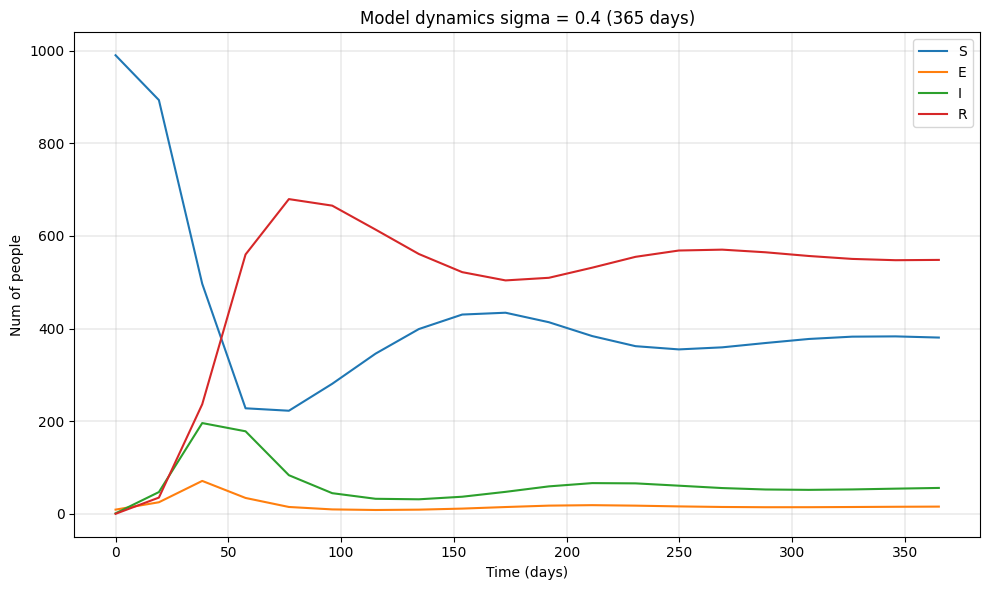

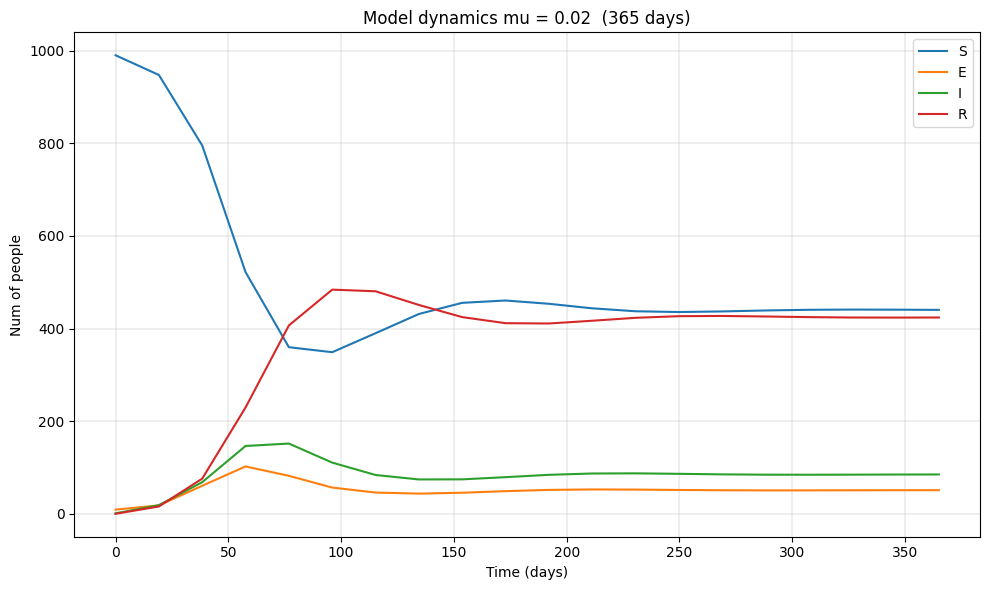

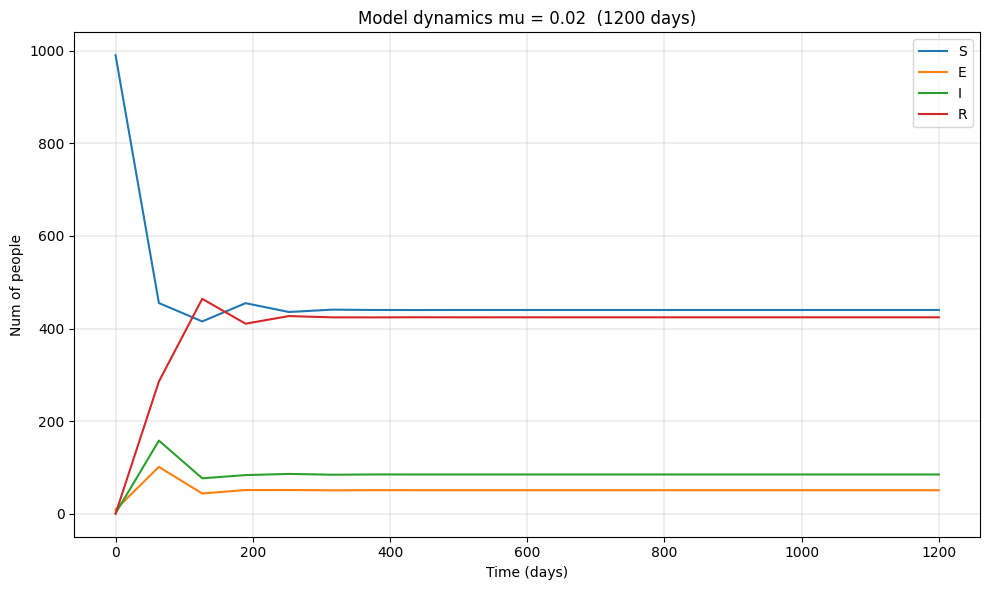

In [4]:
beta  = 0.3e-3
gamma = 0.1
sigma = 0.4
mu    = 0.01
S0, E0, I0, R0 = 990, 9, 1, 0

# 365 days
t1, S1, E1, I1, R1, sol1 = simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0, t_span=(0, 365))
plot(t1, S1, E1, I1, R1, title="Model dynamics sigma = 0.4 (365 days)")

beta  = 0.3e-3
gamma = 0.1
sigma = 0.2
mu    = 0.02
S0, E0, I0, R0 = 990, 9, 1, 0

# 365 days
t1, S1, E1, I1, R1, sol1 = simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0, t_span=(0, 365))
plot(t1, S1, E1, I1, R1, title="Model dynamics mu = 0.02  (365 days)")

# 1200 days
t2, S2, E2, I2, R2, sol2 = simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0, t_span=(0, 1200))
plot(t2, S2, E2, I2, R2, title="Model dynamics mu = 0.02  (1200 days)")

iii.
From the figure, we can observe that the infections rise to a peak, then decline. Small damped oscillations appear before the system settles to a stable state, this oscillation occurs cuz the system behaves like a delayed-feedback system: the exposed class creates a time lag between new infections and the infectious population, producing oscillatory dynamics around the equilibrium. The exposed curve has a very similar pattern compared to infection curve.

iv.
we answer this question based on computational perspective. From the figure, we can observe that increasing the rate of becoming infectious δ makes both the exposed and infection peaks occur earlier because individuals become infectious sooner. Conversely, smaller δ stretches the epidemic wave and reduces the amplitude of oscillations. As for birth/death rates μ, we can observe that increasing the birth/death rates μ changes the long-run model stable state. it makes the recovery population to be lower, but all other states to be higher. Also, we notice that the system stabilizes more quickly because higher μ damps oscillations.

E

/tmp/ipython-input-2835807761.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_inf[i, j] = np.trapz(incidence, t)


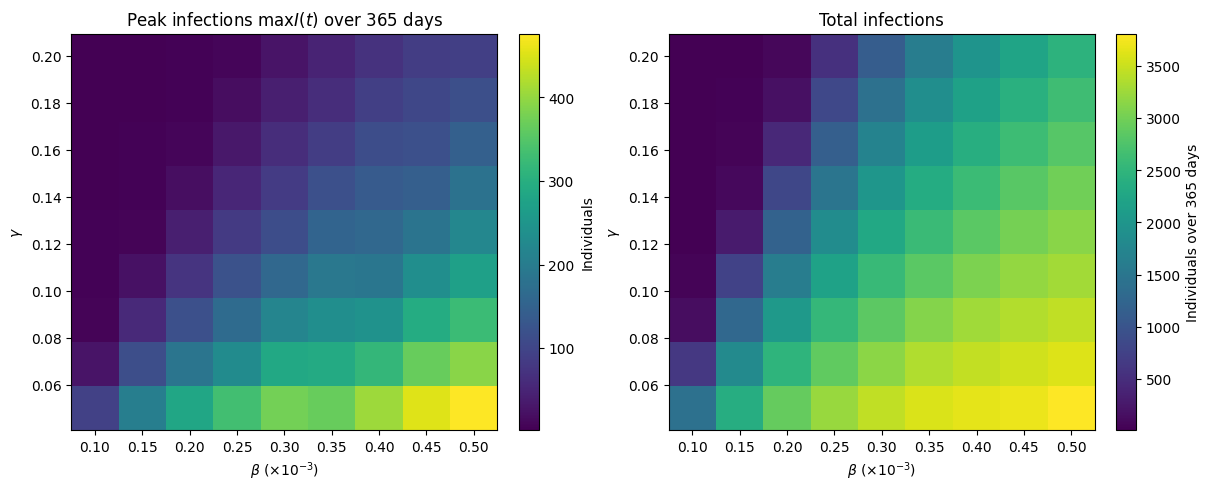

In [5]:
sigma = 0.2
mu    = 0.01
S0, E0, I0, R0 = 990, 9, 1, 0

beta_vals  = np.linspace(0.1e-3, 0.5e-3, 9)
gamma_vals = np.linspace(0.05, 0.2, 9)

peak_I   = np.zeros((len(gamma_vals), len(beta_vals)))
total_inf = np.zeros_like(peak_I)

for i, gamma in enumerate(gamma_vals):
    for j, beta in enumerate(beta_vals):
        t, S, E, I, R, _ = simulate_2(beta, gamma, sigma, mu, S0, E0, I0, R0, t_span=(0, 365))
        peak_I[i, j] = np.max(I)
        incidence = beta * S * I
        total_inf[i, j] = np.trapz(incidence, t)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

B_plot = beta_vals * 1e3
G_plot = gamma_vals

B_mesh, G_mesh = np.meshgrid(B_plot, G_plot)

im0 = axes[0].pcolormesh(B_mesh, G_mesh, peak_I, shading="auto")
axes[0].set_xlabel(r"$\beta$ (×$10^{-3}$)")
axes[0].set_ylabel(r"$\gamma$")
axes[0].set_title("Peak infections $\\max I(t)$ over 365 days")
cb0 = fig.colorbar(im0, ax=axes[0])
cb0.set_label("Individuals")

im1 = axes[1].pcolormesh(B_mesh, G_mesh, total_inf, shading="auto")
axes[1].set_xlabel(r"$\beta$ (×$10^{-3}$)")
axes[1].set_ylabel(r"$\gamma$")
axes[1].set_title("Total infections")
cb1 = fig.colorbar(im1, ax=axes[1])
cb1.set_label("Individuals over 365 days")

plt.show()


iii.
From thr figure, we can conclude that for public health interventions, we should reduce β, which refers to social mixing and transmission per contact.Since, Lower β ⇒ smaller and later infection peaks and fewer total infections. Moreover, we should raise γ, which refers to antivirals, early diagnosis + treatment, supportive care, and effective isolation after symptom. Since  Higher γ ⇒  smaller and later infection peaks and fewer total infections.